# Sickle-cell screening — inference pipeline · deploy-ready

**No training happens in this notebook.** It loads the two checkpoints the earlier notebooks
already trained — a fine-tuned **YOLO11-seg** (`weights/yolo_seg_rbc.pt`, from
`01_segmentation_yolo.ipynb` / `17_final_pipeline.ipynb` cell 3) and a fine-tuned
**InceptionV3** (`weights/cls_inceptionv3.pt`, from `06_classifier_inceptionv3.ipynb` /
`17_final_pipeline.ipynb` cell 4) — and wires them into the shape a real deployment takes:
**upload a blood smear → get an annotated image + a sickle-fraction report back.**

| file | role |
|---|---|
| [`scd_inference.py`](scd_inference.py) | the actual pipeline: locate checkpoints, load models once, `analyze_blood_sample()` |
| `18_inference_pipeline.ipynb` (this file) | demo / dev harness — same import, same function, run interactively |
| [`app.py`](app.py) | the web service — a FastAPI app around the exact same function |

Both this notebook and `app.py` import `scd_inference.py`. There is exactly one place the
segment → crop → classify → annotate logic lives, so a bug fixed here is fixed everywhere.

| cell | what it does |
|---|---|
| **1 · locate checkpoints** | resolves `runs_two_stage/weights/*.pt`, verifies they exist, prints what will be used |
| **2 · load models** | loads YOLO-seg + InceptionV3 once, cross-references the metrics they scored during training |
| **3 · run inference** | one smear in → annotated overlay + per-cell JSON out |
| **4 · simulate a website upload** | an `ipywidgets` upload box wired to the same function a browser upload would hit |
| **5 · batch mode** | score every image in a folder, write one summary CSV |
| **6 · the deployable service** | `app.py` (FastAPI) exercised in-process with `TestClient` — no server to stand up to try it |
| **7 · run log** | appends to the same `checkpoints.json` the training notebooks write |

### Before running this

The checkpoints must already exist. If `01`/`06` (or `17_final_pipeline.ipynb`) have not been
run yet, cell 1 below fails with an error naming exactly which notebook to run first and
which file it is missing — that failure is deliberate, not a bug: this pipeline refuses to
score blood samples with an untrained or missing model.

`runs_two_stage/` is found the same way the training notebooks resolve it (`SCD_RUNS_DIR`,
else `/ibex/user/$USER/runs_two_stage` on IBEX). A deployment that ships only the two `.pt`
files can skip that entirely with `SCD_YOLO_CKPT=/path/to/yolo_seg_rbc.pt` and
`SCD_CLS_CKPT=/path/to/cls_inceptionv3.pt`.

## 1 · Locate and verify the trained checkpoints

`scd_inference.resolve_checkpoints()` uses the *same* `runs_dir` resolution the training
notebooks use, so it finds exactly what they wrote — not a copy, not a guess. It also reads
`runs_two_stage/checkpoints.json`, the append-only run log every training notebook writes to,
and pulls back the metrics (F1@IoU0.5, macro-F1, …) that were recorded the moment each
checkpoint was produced. That is the concrete answer to *"are these really the trained
weights?"* — printed, not assumed.

In [4]:
import sys, os, json

# Where THIS notebook's folder actually is. Deliberately NOT auto-detected: the kernel's cwd
# and every frontend hint (VS Code's own notebook-path variable included) have each pointed
# somewhere else in different remote-kernel setups -- the workspace root in one, a totally
# unrelated user's $HOME in another. /ibex is the one thing every kernel on this cluster
# mounts the same way, so the fixed path below is more reliable than guessing.
# Override with SCD_NB_DIR if this notebook is copied somewhere else.
NB_DIR = os.environ.get("SCD_NB_DIR", "/ibex/user/mandoraa/scd17/notebook")
if not os.path.isfile(os.path.join(NB_DIR, "scd_inference.py")):
    raise FileNotFoundError(
        f"scd_inference.py not found at {NB_DIR}.\n"
        "  export SCD_NB_DIR=/actual/path/to/this/notebooks/folder, or edit NB_DIR above.")
sys.path.insert(0, NB_DIR)
import scd_inference as si

info = si.resolve_checkpoints()
print(f"runs_dir   {info['runs_dir']}")
print(f"device     {si.GPU}  (tier {si.TIER!r})")
print()
for key, label in (('yolo', 'segmentation · YOLO-seg'), ('cls', 'classification · InceptionV3')):
    print(f"{label}")
    print(f"  checkpoint   {info[f'{key}_ckpt']}")
    print(f"  size         {info[f'{key}_mb']} MB   modified {info[f'{key}_modified']}")
    m = info.get(f'{key}_trained_metrics')
    if m:
        print(f"  as-trained metrics   " + ', '.join(f'{k}={v}' for k, v in m.items()))
    else:
        print('  (no matching entry in checkpoints.json -- metrics unknown, but the file exists)')
    print()

runs_dir   /ibex/user/bahajao/runs_two_stage
device     NVIDIA A100-SXM4-80GB  (tier 'a100')

segmentation · YOLO-seg
  checkpoint   /ibex/user/bahajao/runs_two_stage/weights/yolo_seg_rbc.pt
  size         43.15 MB   modified 2026-08-04 12:14
  as-trained metrics   f1@50=0.664115, precision@50=0.5, recall@50=0.988604, mask_ap50=0.854359, mask_ap50_95=0.713856, mean_matched_iou=0.894781, sec_per_smear=0.105169, ultralytics_mask_mAP50=0.75451

classification · InceptionV3
  checkpoint   /ibex/user/bahajao/runs_two_stage/weights/cls_inceptionv3.pt
  size         93.22 MB   modified 2026-08-04 12:15
  as-trained metrics   macro_f1=1.0, accuracy=1.0, auc=1.0, f1_circular=1.0, f1_elongated=1.0, params_M=24.3489, ms_per_crop=5.126423, best_val_f1=1.0



In [5]:
!pwd

/home/bahajao


## 2 · Load the models

Loaded once and cached (`si.get_models()`) — a real deployment loads weights at process
startup, not per request. `app.py` calls this exact function in a FastAPI `startup` event.

In [6]:
models = si.get_models()
print(f"loaded at {models['loaded_at']}  |  device {models['device']}  |  tier {models['tier']}")
print(f"YOLO-seg     : {models['info']['yolo_ckpt']}")
print(f"InceptionV3  : {models['info']['cls_ckpt']}")

loaded at 2026-08-04 16:37:09  |  device cuda  |  tier a100
YOLO-seg     : /ibex/user/bahajao/runs_two_stage/weights/yolo_seg_rbc.pt
InceptionV3  : /ibex/user/bahajao/runs_two_stage/weights/cls_inceptionv3.pt


## 3 · Run inference on one smear, stage by stage

Instead of calling `analyze_blood_sample()` as one black box, this section calls each stage
of the pipeline directly — `load_rgb_any` → `segment` → `crop_cells` → `classify` →
`render_overlay`, the exact same functions `analyze_blood_sample()` composes internally —
and shows what the demo image looks like after every step:

| stage | function | what you'll see |
|---|---|---|
| 0 · load | `si.load_rgb_any` | the raw smear, resized to the inference cap |
| 1 · segment | `si.segment` (YOLO-seg) | every detected cell outlined, no class assigned yet |
| 2 · crop | `si.crop_cells` | the padded per-cell crops actually handed to the classifier |
| 3 · classify | `si.classify` (InceptionV3) | each crop labeled circular/elongated with its probability |
| 4 · overlay | `si.render_overlay` | the final annotated image — green = circular, red = elongated |
| — | — | just the cells classified elongated (sickled), isolated |

Set `DEMO_IMAGE` to any smear on disk. If left `None`, the cell below looks for one
automatically: first the held-out validation smears `17_final_pipeline.ipynb` produced,
otherwise one image pulled straight out of the dataset zip.

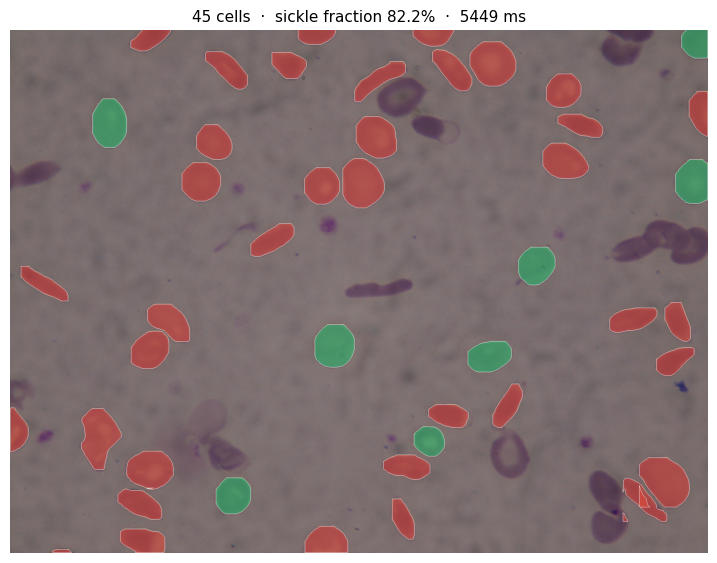

{
  "n_cells_detected": 45,
  "n_circular": 8,
  "n_elongated": 37,
  "sickle_fraction": 0.8222,
  "model_info": {
    "runs_dir": "/ibex/user/bahajao/runs_two_stage",
    "yolo_ckpt": "/ibex/user/bahajao/runs_two_stage/weights/yolo_seg_rbc.pt",
    "cls_ckpt": "/ibex/user/bahajao/runs_two_stage/weights/cls_inceptionv3.pt",
    "yolo_modified": "2026-08-04 12:14",
    "yolo_trained_metrics": {
      "f1@50": 0.664115,
      "precision@50": 0.5,
      "recall@50": 0.988604,
      "mask_ap50": 0.854359,
      "mask_ap50_95": 0.713856,
      "mean_matched_iou": 0.894781,
      "sec_per_smear": 0.105169,
      "ultralytics_mask_mAP50": 0.75451
    },
    "cls_modified": "2026-08-04 12:15",
    "cls_trained_metrics": {
      "macro_f1": 1.0,
      "accuracy": 1.0,
      "auc": 1.0,
      "f1_circular": 1.0,
      "f1_elongated": 1.0,
      "params_M": 24.3489,
      "ms_per_crop": 5.126423,
      "best_val_f1": 1.0
    }
  },
  "device": "cuda",
  "tier": "a100",
  "inference_ms": 5448.7,
 

In [7]:
import base64, glob, zipfile, cv2, numpy as np
import matplotlib.pyplot as plt

DEMO_IMAGE = None                            # <- point this at any blood-smear image to try your own


def find_demo_image():
    if DEMO_IMAGE:
        return DEMO_IMAGE
    val_glob = os.path.join(si.RUNS_DIR, 'seg_ds', 'images', 'val', '*')
    hit = next(iter(sorted(glob.glob(val_glob))), '')
    if hit:
        return hit
    for zip_path in (os.environ.get('SCD_DATA_ZIP', ''),
                     '/ibex/user/mandoraa/scd17/data/Sickle_Cell_Dataset_1.zip'):
        if zip_path and os.path.isfile(zip_path):
            with zipfile.ZipFile(zip_path) as zf:
                name = next((n for n in zf.namelist()
                            if n.lower().endswith(('.jpg', '.jpeg', '.png')) and
                            'full_smear' in n.lower()), '')
                if name:
                    return zf.read(name)          # raw bytes -- analyze_blood_sample accepts these too
    raise FileNotFoundError('no demo image found -- set DEMO_IMAGE to a smear on disk')


sample = find_demo_image()
result = si.analyze_blood_sample(sample, models=models)

overlay_bytes = base64.b64decode(result.pop('annotated_image_png_base64'))
overlay = cv2.imdecode(np.frombuffer(overlay_bytes, np.uint8), cv2.IMREAD_COLOR)
overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(overlay)
ax.axis('off')
ax.set_title(f"{result['n_cells_detected']} cells  ·  "
             f"sickle fraction {result['sickle_fraction'] * 100:.1f}%  ·  "
             f"{result['inference_ms']:.0f} ms", fontsize=11)
plt.show()

print(json.dumps({k: v for k, v in result.items() if k != 'cells'}, indent=2))
print(f"\nfirst few cells: {json.dumps(result['cells'][:3], indent=2)}")

## 4 · Simulate a website upload, right here in the notebook

A real deployment's frontend hands `app.py` raw file bytes from a browser upload. This
`ipywidgets.FileUpload` box does the same thing inside Jupyter: drop any smear image on it
and it runs through `analyze_blood_sample()` exactly as `POST /predict` would.

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

uploader = widgets.FileUpload(accept='image/*', multiple=False, description='Upload a smear')
out = widgets.Output()


def _on_upload(change):
    with out:
        clear_output(wait=True)
        if not uploader.value:
            return
        item = uploader.value[0] if isinstance(uploader.value, (list, tuple)) else \
            next(iter(uploader.value.values()))
        raw = item['content'] if isinstance(item.get('content'), (bytes, bytearray)) else bytes(item['content'])
        r = si.analyze_blood_sample(raw, models=models)
        ov = cv2.cvtColor(cv2.imdecode(np.frombuffer(base64.b64decode(
            r.pop('annotated_image_png_base64')), np.uint8), cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.imshow(ov)
        ax.axis('off')
        ax.set_title(f"{r['n_cells_detected']} cells  ·  sickle {r['sickle_fraction'] * 100:.1f}%")
        plt.show()
        print(json.dumps({k: v for k, v in r.items() if k != 'cells'}, indent=2))


uploader.observe(_on_upload, names='value')
display(uploader, out)

FileUpload(value=(), accept='image/*', description='Upload a smear')

Output()

## 5 · Batch mode — score a whole folder

The same function, looped over every image in a directory — useful for scoring a batch of
uploads offline, or for regression-checking a new checkpoint against a folder of known
smears. Writes one row per image to `runs_two_stage/tables/inference_batch.csv`.

In [9]:
import pandas as pd

INPUT_DIR = None                             # <- a folder of smear images; None skips this cell

if INPUT_DIR and os.path.isdir(INPUT_DIR):
    rows = []
    for p in sorted(glob.glob(os.path.join(INPUT_DIR, '*'))):
        try:
            r = si.analyze_blood_sample(p, models=models, return_image=False)
            rows.append({'image': os.path.basename(p), 'n_cells': r['n_cells_detected'],
                        'n_elongated': r['n_elongated'], 'sickle_fraction': r['sickle_fraction'],
                        'inference_ms': r['inference_ms']})
        except Exception as e:
            rows.append({'image': os.path.basename(p), 'error': str(e)})
    batch = pd.DataFrame(rows)
    out_csv = os.path.join(si.RUNS_DIR, 'tables', 'inference_batch.csv')
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    batch.to_csv(out_csv, index=False)
    print(batch.to_string(index=False))
    print(f'\nwrote {out_csv}')
else:
    print('INPUT_DIR not set -- skipping batch mode (set it to a folder of smear images to use it)')

INPUT_DIR not set -- skipping batch mode (set it to a folder of smear images to use it)


## 6 · The deployable service — `app.py`

`app.py` is a small FastAPI app that loads the models once at startup and exposes:

* `GET /health` — which checkpoints are loaded, their modified times, the device/tier
* `POST /predict` — upload a smear, get back the same JSON `analyze_blood_sample()` returns

To actually deploy it:

```bash
uvicorn app:app --host 0.0.0.0 --port 8000
```

Then open `http://<host>:8000/docs` — FastAPI's Swagger UI is a working upload form in the
browser, which is the "website" this pipeline was built to sit behind. No separate frontend
is required to try it; wire a real page's upload button to `POST /predict` when one exists.

The cell below runs `app.py` **in-process** with FastAPI's `TestClient` — it proves the
service works without leaving the notebook or opening a port.

In [10]:
import app as web_app
from fastapi.testclient import TestClient

with TestClient(web_app.app) as client:
    print('GET /health ->', client.get('/health').json())

    sample = find_demo_image()
    file_bytes = open(sample, 'rb').read() if isinstance(sample, str) else sample
    r = client.post('/predict', files={'file': ('smear.jpg', file_bytes, 'image/jpeg')})
    print('\nPOST /predict ->', r.status_code)
    body = r.json()
    print(json.dumps({k: v for k, v in body.items() if k != 'annotated_image_png_base64'}, indent=2))

Form data requires "python-multipart" to be installed. 
You can install "python-multipart" with: 

pip install python-multipart



RuntimeError: Form data requires "python-multipart" to be installed. 
You can install "python-multipart" with: 

pip install python-multipart


## 7 · Run log

Same `checkpoints.json` the training notebooks append to (`runs_two_stage/checkpoints.json`)
— this run lands in the same history as the stages that produced the checkpoints it used, so
`pd.DataFrame(json.load(open('runs_two_stage/checkpoints.json')))` still tells the whole
pipeline's story, training and inference alike.

In [ ]:
rec = si.log_run('inference_demo',
                 metrics={'demo_cells_detected': result['n_cells_detected'],
                          'demo_sickle_fraction': result['sickle_fraction'],
                          'demo_inference_ms': result['inference_ms']},
                 notes='18_inference_pipeline.ipynb -- interactive + API smoke test')
print(json.dumps(rec, indent=2))